<a href="https://colab.research.google.com/github/eduardo-illueca/icg-project/blob/main/Detection/HC_Model_all_subjects_v17.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This notebook applies the Characteristic Point Detector (model_v4.keras), trained on the ReBeat database, to the HeartCycle database. We evaluate the detector's robustness against signal variations and changes in hemodynamic parameters. Signal processing steps are preserved to maintain access to the variables used during training.

# Load Data

We load the data from Google Drive.

In [1]:
import os
import numpy as np
import pandas as pd
import scipy.io as sio
import matplotlib.pyplot as plt
from google.colab import drive

from scipy.signal import butter, filtfilt, savgol_filter, resample
from scipy.stats import pearsonr
from sklearn.preprocessing import StandardScaler  # Z-score scaler

from tensorflow.keras.models import load_model

In [2]:
def preprocess_icg_detrend(icg_data, icg_time, fs, lowcut=0.7, highcut=20.0, order=2, sg_window=301, sg_poly=2):
    # Bandpass filter
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    icg_bandpassed = filtfilt(b, a, icg_data)

    # Baseline estimation using SG and subtraction
    baseline = savgol_filter(icg_bandpassed, window_length=sg_window, polyorder=sg_poly)
    icg_detrended = icg_bandpassed - baseline

    return icg_detrended

In [3]:
def bandpass(signal, fs, lowcut, highcut, order=2):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, signal)

In [4]:
import scipy.io as sio
import numpy as np
import os
from scipy.signal import butter, filtfilt, savgol_filter
from sklearn.preprocessing import StandardScaler
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# --- Preprocessing function ---
def preprocess_signals(icg_data, icg_time, ecg_data, fs_icg=200, fs_ecg=200):
    nyq_icg = 0.5 * fs_icg
    low_icg = 0.7 / nyq_icg
    high_icg = 20.0 / nyq_icg
    b_icg, a_icg = butter(N=2, Wn=[low_icg, high_icg], btype='band')
    icg_bandpassed = filtfilt(b_icg, a_icg, icg_data)

    baseline = savgol_filter(icg_bandpassed, window_length=301, polyorder=2)
    icg_detrended = icg_bandpassed - baseline

    dt = np.mean(np.diff(icg_time))
    dz_dt = np.gradient(icg_detrended, dt)

    scaler_icg = StandardScaler()
    dz_dt_norm = scaler_icg.fit_transform(dz_dt.reshape(-1, 1)).flatten()

    nyq_ecg = 0.5 * fs_ecg
    low_ecg = 0.5 / nyq_ecg
    high_ecg = 45.0 / nyq_ecg
    b_ecg, a_ecg = butter(N=2, Wn=[low_ecg, high_ecg], btype='band')
    ecg_bandpassed = filtfilt(b_ecg, a_ecg, ecg_data)

    scaler_ecg = StandardScaler()
    ecg_norm = scaler_ecg.fit_transform(ecg_bandpassed.reshape(-1, 1)).flatten()

    return dz_dt_norm, ecg_norm

# --- Initialize output ---
all_data = {}

# --- Define folder + file loop structure ---
file_specs = [
    {
        "dir": "/content/drive/MyDrive/TFG/Data_HeartCycle/59146237",
        "prefix": "",
        "range": range(1, 38)
    },
    {
        "dir": "/content/drive/MyDrive/TFG/Data_HeartCycle/59146238",
        "prefix": "",
        "range": [i for i in range(1, 84) if i != 42]
    },
    {
        "dir": "/content/drive/MyDrive/TFG/Data_HeartCycle/59146239",
        "custom_files": (
            [("CH17_", i) for i in range(1, 15)] +
            [("CH16_", i) for i in range(15, 26)] +
            [("CH15_", i) for i in range(38, 43)]
        )
    }
]

# --- Main processing loop ---
for spec in file_specs:
    dir_path = spec["dir"]

    if "custom_files" in spec:
        file_list = spec["custom_files"]
    else:
        file_list = [(spec["prefix"], i) for i in spec["range"]]

    for prefix, i in file_list:
        filename = f"{prefix}591462{dir_path[-2:]}_s00000{i:02d}.mat"
        file_path = os.path.join(dir_path, filename)

        if not os.path.exists(file_path):
            print(f"File not found: {file_path}")
            continue

        print(f"\nProcessing file: {filename}")
        try:
            data_hc = sio.loadmat(file_path)

            if 'measure' not in data_hc:
                print("No 'measure' key found.")
                continue

            measures = data_hc['measure']

            icg = measures[1, 1]
            icg_time = icg['time'][0, 0].flatten()
            icg_data = icg['data'][0, 0].flatten()

            ecg = measures[0, 1]
            ecg_time = ecg['time'][0, 0].flatten()
            ecg_data = ecg['data'][0, 0].flatten()

            rpeaks = measures[2, 1]
            rpeaks_times = rpeaks['data'][0, 0].flatten()
            rpeaks_indices = np.array([np.argmin(np.abs(ecg_time - t)) for t in rpeaks_times])

            pep_values = measures[4, 1]['data'][0, 0].flatten()
            lvet_values = measures[6, 1]['data'][0, 0].flatten()

            dz_dt_norm, ecg_norm = preprocess_signals(
                icg_data=icg_data,
                icg_time=icg_time,
                ecg_data=ecg_data,
                fs_icg=200,
                fs_ecg=200
            )

            all_data[filename] = {
                "dz_dt_norm": dz_dt_norm,
                "ecg_norm": ecg_norm,
                "icg_time": icg_time,
                "ecg_time": ecg_time,
                "rpeaks_time": rpeaks_times,
                "rpeaks_index": rpeaks_indices,
                "pep_ms": pep_values,
                "lvet_ms": lvet_values
            }

        except Exception as e:
            print(f"Error processing {filename}: {e}")
            continue


Mounted at /content/drive

Processing file: 59146237_s0000001.mat

Processing file: 59146237_s0000002.mat

Processing file: 59146237_s0000003.mat

Processing file: 59146237_s0000004.mat

Processing file: 59146237_s0000005.mat

Processing file: 59146237_s0000006.mat

Processing file: 59146237_s0000007.mat

Processing file: 59146237_s0000008.mat

Processing file: 59146237_s0000009.mat

Processing file: 59146237_s0000010.mat

Processing file: 59146237_s0000011.mat

Processing file: 59146237_s0000012.mat

Processing file: 59146237_s0000013.mat

Processing file: 59146237_s0000014.mat

Processing file: 59146237_s0000015.mat

Processing file: 59146237_s0000016.mat

Processing file: 59146237_s0000017.mat

Processing file: 59146237_s0000018.mat

Processing file: 59146237_s0000019.mat

Processing file: 59146237_s0000020.mat

Processing file: 59146237_s0000021.mat

Processing file: 59146237_s0000022.mat

Processing file: 59146237_s0000023.mat

Processing file: 59146237_s0000024.mat

Processing fi

## Model

In [5]:
def segment_icg(signal, r_indices, fs=250, pre_r=0.2, post_r=0.6, n_segments_to_plot=5):
    """
    Extract and normalize segments around R-peaks, plot them (ICG or ECG).

    Parameters:
        signal (array): Full ICG or ECG signal
        r_indices (array): Indices of R-peaks
        fs (int): Sampling frequency (Hz)
        pre_r (float): Time before R in seconds
        post_r (float): Time after R in seconds
        n_segments_to_plot (int): Number of segments to plot

    Returns:
        segments (array): Normalized segments, shape [n_segments, segment_len]
    """
    segment_len = int((pre_r + post_r) * fs)
    offset = int(pre_r * fs)
    segments = []

    for r in r_indices:
        start = r - offset
        end = start + segment_len
        if start >= 0 and end <= len(signal):
            segment = signal[start:end]
            segment = (segment - np.mean(segment)) / (np.std(segment) + 1e-8)
            segments.append(segment)

    segments = np.array(segments)

    #Plot extracted segments
    # plt.figure(figsize=(12, 8))
    # for i in range(min(n_segments_to_plot, len(segments))):
    #     plt.plot(segments[i], label=f'Segment {i+1}')
    #     plt.scatter(offset, segments[i][offset], color='red', marker='x', s=100, label='R-peak' if i == 0 else "")
    # plt.xlabel('Sample')
    # plt.ylabel('Amplitude (normalized)')
    # plt.title('Extracted Segments Around R-Peaks')
    # plt.legend()
    # plt.grid(True)
    # plt.show()

    return segments


def upsample_segments(segments_old, from_fs=200, to_fs=250):
    """
    Upsample segments only if needed (e.g., HeartCycle from 200 Hz to 250 Hz).

    Parameters:
        segments_old (array): Input segments, shape [n_segments, old_len]
        from_fs (int): Original sampling frequency
        to_fs (int): Target sampling frequency

    Returns:
        segments_upsampled (array): Segments with resampled length
    """
    if from_fs == to_fs:
        return segments_old
    new_len = int(segments_old.shape[1] * to_fs / from_fs)
    return np.array([resample(seg, new_len) for seg in segments_old])


def prepare_icg_model_input(icg_segments_upsampled, ecg_segments_upsampled):
    """
    Stack ICG and ECG into shape [n_segments, 200, 2] for model input.
    Assumes both are already resampled to 200 samples and normalized.

    Returns:
        X_input (array): Input to model, shape [n_segments, 200, 2]
    """
    return np.stack([icg_segments_upsampled, ecg_segments_upsampled], axis=-1)


In [6]:
X_all = []  # will hold all model inputs (n_segments, 200, 2)

for filename, data in all_data.items():
    try:
        dz_dt = data["dz_dt_norm"]
        ecg_norm = data["ecg_norm"]
        rpeaks_index = data["rpeaks_index"]

        # Segment at 200 Hz
        icg_segments = segment_icg(dz_dt, rpeaks_index, fs=200)
        ecg_segments = segment_icg(ecg_norm, rpeaks_index, fs=200)

        # Upsample to 250 Hz
        icg_segments_upsampled = upsample_segments(icg_segments, from_fs=200, to_fs=250)
        ecg_segments_upsampled = upsample_segments(ecg_segments, from_fs=200, to_fs=250)

        # Prepare model input (n_segments, 200, 2)
        X_input = prepare_icg_model_input(icg_segments_upsampled, ecg_segments_upsampled)

        X_all.append(X_input)

        print(f"{filename}: added {X_input.shape[0]} segments")

    except Exception as e:
        print(f"Error in {filename}: {e}")
        continue

# Final stacked input
X_all = np.vstack(X_all)  # shape: (total_segments, 200, 2)
print("Final model input shape:", X_all.shape)

59146237_s0000001.mat: added 2 segments
59146237_s0000002.mat: added 9 segments
59146237_s0000003.mat: added 8 segments
59146237_s0000004.mat: added 8 segments
59146237_s0000005.mat: added 9 segments
59146237_s0000006.mat: added 8 segments
59146237_s0000007.mat: added 9 segments
59146237_s0000008.mat: added 9 segments
59146237_s0000009.mat: added 8 segments
59146237_s0000010.mat: added 8 segments
59146237_s0000011.mat: added 8 segments
59146237_s0000012.mat: added 8 segments
59146237_s0000013.mat: added 9 segments
59146237_s0000014.mat: added 8 segments
59146237_s0000015.mat: added 9 segments
59146237_s0000016.mat: added 8 segments
59146237_s0000017.mat: added 8 segments
59146237_s0000018.mat: added 8 segments
59146237_s0000019.mat: added 8 segments
59146237_s0000020.mat: added 8 segments
59146237_s0000021.mat: added 8 segments
59146237_s0000022.mat: added 8 segments
59146237_s0000023.mat: added 8 segments
59146237_s0000024.mat: added 8 segments
59146237_s0000025.mat: added 8 segments


In [7]:
from google.colab import files
uploaded = files.upload()
model = list(uploaded.keys())[0]

Saving model_v17.keras to model_v17.keras


In [75]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model  # or however you load your model

# 1. Model input normalization per segment
def create_model_input(ecg_segments, icg_segments):
    assert ecg_segments.shape == icg_segments.shape, "Shapes must match"
    ecg_norm = (ecg_segments - np.mean(ecg_segments, axis=1, keepdims=True)) / (np.std(ecg_segments, axis=1, keepdims=True) + 1e-8)
    icg_norm = (icg_segments - np.mean(icg_segments, axis=1, keepdims=True)) / (np.std(icg_segments, axis=1, keepdims=True) + 1e-8)
    return np.stack([icg_norm, ecg_norm], axis=-1)  # shape: (n_segments, 200, 2)

# 2. Extract B, X, O predicted positions from model output
def extract_predicted_points(y_pred):
    return np.argmax(y_pred, axis=1)  # shape: (n_segments, 3)

# 3. Plot ICG + predicted B, X, O points
def plot_icg_with_predicted_points(icg_segments, predicted_points, n_segments_to_plot=5):
    labels = ['B', 'X', 'O']
    colors = ['blue', 'green', 'red']

    plt.figure(figsize=(15, n_segments_to_plot * 3))
    for i in range(min(n_segments_to_plot, len(icg_segments))):
        plt.subplot(n_segments_to_plot, 1, i + 1)
        plt.plot(icg_segments[i], label='ICG Signal', color='black')
        for j, label_name in enumerate(labels):
            idx = predicted_points[i, j]
            if 0 <= idx < icg_segments.shape[1]:
                plt.plot(idx, icg_segments[i, idx], 'o', color=colors[j], label=f'Predicted {label_name}')
        plt.title(f'Segment {i+1} — Predicted Points (B, X, O)')
        plt.xlabel('Sample')
        plt.ylabel('ICG Amplitude')
        plt.legend()
        plt.grid(True)
    plt.tight_layout()
    plt.show()

37/37 ━━━━━━━━━━━━━━━━━━━━ 19s 337ms/step


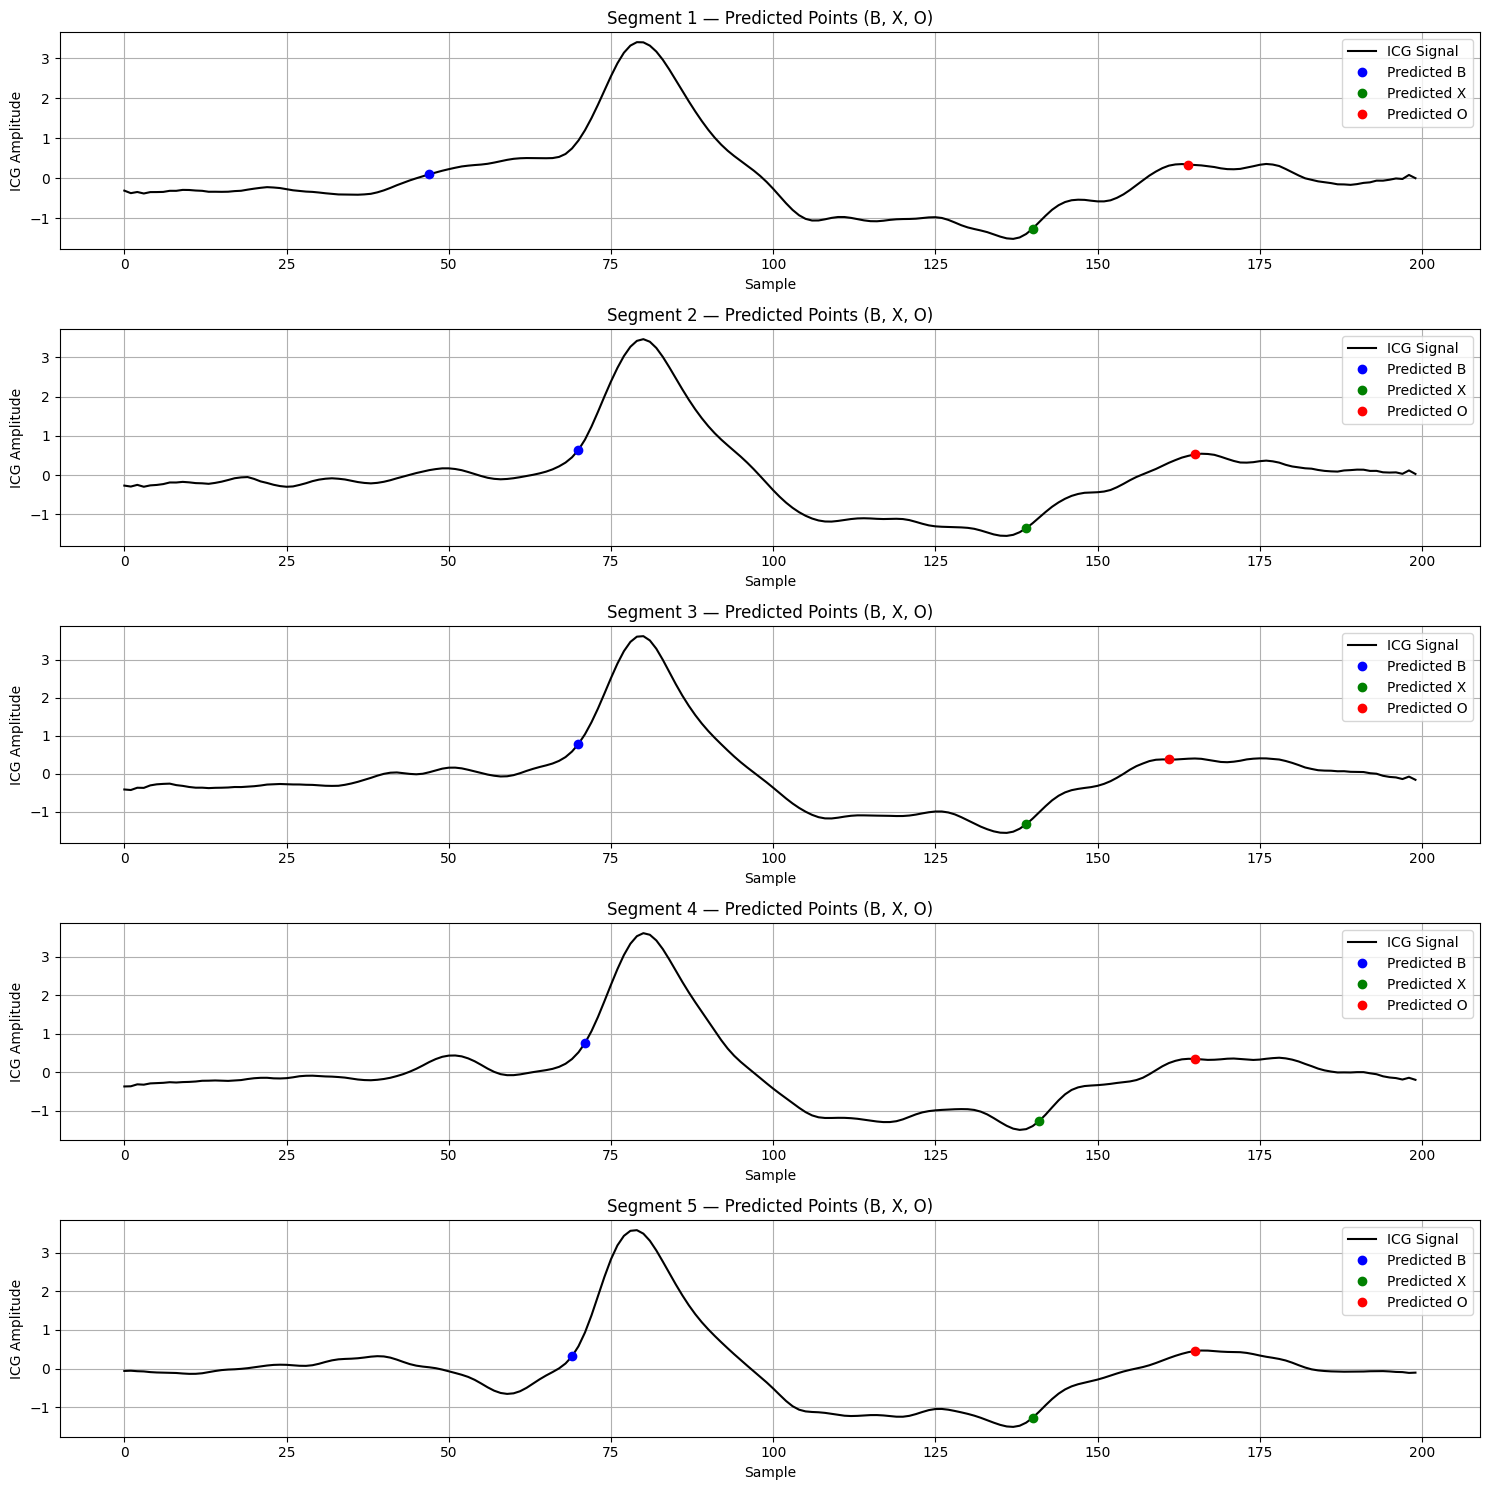

In [76]:
# 4. Split channels
icg_segments_all = X_all[:, :, 0]
ecg_segments_all = X_all[:, :, 1]

# 5. Normalize per segment
X_input_all = create_model_input(ecg_segments_all, icg_segments_all)

# 6. Load trained model
predictor = load_model(model, compile=False)

# 7. Predict
y_pred_all = predictor.predict(X_input_all)  # shape: (n segments, 200, 3)

# 8. Extract predicted time indices for B, X, O
predicted_labels_all = extract_predicted_points(y_pred_all)  # shape: (628, 3)

# 9. Plot a few segments
plot_icg_with_predicted_points(X_input_all[:, :, 0], predicted_labels_all, n_segments_to_plot=5)


## C peak detection

In [83]:
def detect_c_peak_after_r(icg_segments, predicted_bxo, offset=50, fs=250):
    """
    Detect C peaks as the maximum in a window after the R-peak in each segment.

    Parameters:
        icg_segments: np.array of shape (n_segments, segment_len)
        predicted_bxo: np.array of shape (n_segments, 3)
        offset: index of R-peak in each segment
        fs: sampling frequency

    Returns:
        predicted_b_c_x_o: np.array of shape (n_segments, 4)
    """
    c_indices = []
    window_length = int(0.3 * fs)  # 100 ms

    for i in range(len(icg_segments)):
        seg = icg_segments[i]
        start = offset
        end = min(offset + window_length, len(seg))

        search_window = seg[start:end]
        if len(search_window) > 0:
            c_rel = np.argmax(search_window)
            c = start + c_rel
        else:
            c = offset  # fallback
        c_indices.append(c)

    c_indices = np.array(c_indices).reshape(-1, 1)  # shape (n_segments, 1)

    # Insert C between B and X
    predicted_b_c_x_o = np.concatenate([
        predicted_bxo[:, :1],  # B
        c_indices,             # C
        predicted_bxo[:, 1:]   # X, O
    ], axis=1)

    return predicted_b_c_x_o

In [84]:
def plot_icg_with_predicted_points(icg_segments, predicted_points, n_segments_to_plot=8):
    """
    Plots ICG segments and marks predicted B, C, X, O points.
    """
    labels = ['B', 'C', 'X', 'O']
    colors = ['blue', 'orange', 'green', 'red']

    plt.figure(figsize=(14, n_segments_to_plot * 3))
    for i in range(min(n_segments_to_plot, len(icg_segments))):
        plt.subplot(n_segments_to_plot, 1, i + 1)
        plt.plot(icg_segments[i], label='ICG Signal', color='black')

        for j, (label_name, color) in enumerate(zip(labels, colors)):
            idx = predicted_points[i, j]
            if 0 <= idx < icg_segments.shape[1]:
                plt.plot(idx, icg_segments[i, idx], 'o', color=color, label=f'Predicted {label_name}')

        plt.title(f'Segment {i+1} — Predicted Points (B, C, X, O)')
        plt.xlabel('Sample')
        plt.ylabel('ICG Amplitude')
        if i == 0:
            plt.legend()  # only on first plot
        plt.grid(True)

    plt.tight_layout()
    plt.show()


In [85]:
fs = 250
offset = int(0.2 * fs)  # R-peak index in segment (50 samples)

# Extract ICG signal
icg_segments_all = X_input_all[:, :, 0]  # shape: (n_segments, 200)
print("ICG segments shape:", icg_segments_all.shape)

# Detect B, C, X, O
predicted_b_c_x_o_all = detect_c_peak_after_r(
    icg_segments_all, predicted_labels_all, offset=offset, fs=fs
)

#Convert to float array for NaN support
corrected = predicted_b_c_x_o_all.astype(float)

# === Step 1: Flag bad X-points (too early after R-peak) ===
for i in range(len(corrected)):
    x = corrected[i, 2]
    if x < offset + int(0.1 * fs):  # 100ms after R-peak
        corrected[i, 2] = np.nan
        print(f"Flagged early X at segment {i}: original X = {x}")

# === Step 2: Flag bad B-points ===
min_pep = int(0.03 * fs)  # 30 ms
max_pep = int(0.13 * fs)  # 130 ms

bad_b_indices = []

for i in range(len(corrected)):
    b, c = corrected[i, 0], corrected[i, 1]

    if np.isnan(b) or np.isnan(c):
        bad_b_indices.append(i)
        continue

    if b < offset:  # before R-peak
        bad_b_indices.append(i)
        continue

    if b >= c:  # B after C
        bad_b_indices.append(i)
        continue

    pep = b - offset
    if pep < min_pep or pep > max_pep:
        bad_b_indices.append(i)

# Mark bad B-points as NaN
corrected[bad_b_indices, 0] = np.nan
print(f"Flagged {len(bad_b_indices)} bad B-points.")


ICG segments shape: (1155, 200)
Flagged early X at segment 396: original X = 29.0
Flagged early X at segment 429: original X = 30.0
Flagged early X at segment 434: original X = 24.0
Flagged early X at segment 705: original X = 28.0
Flagged early X at segment 794: original X = 28.0
Flagged early X at segment 815: original X = 29.0
Flagged early X at segment 1033: original X = 25.0
Flagged early X at segment 1034: original X = 19.0
Flagged early X at segment 1041: original X = 23.0
Flagged early X at segment 1042: original X = 24.0
Flagged early X at segment 1043: original X = 21.0
Flagged early X at segment 1051: original X = 22.0
Flagged early X at segment 1066: original X = 25.0
Flagged early X at segment 1067: original X = 24.0
Flagged early X at segment 1070: original X = 21.0
Flagged early X at segment 1073: original X = 21.0
Flagged early X at segment 1079: original X = 21.0
Flagged early X at segment 1080: original X = 20.0
Flagged early X at segment 1082: original X = 25.0
Flagg

In [41]:
print(predicted_labels_all.shape)
print(predicted_b_c_x_o_all.shape)

(1155, 3)
(1155, 4)


In [86]:
def detect_physiological_outliers(y_bcxo, r_peaks):
    """
    Returns a dictionary with boolean masks indicating outliers per point (B, C, X, O),
    based on expected temporal order between points.

    Parameters:
        y_bcxo: np.ndarray of shape (n_samples, 4) — true B, C, X, O sample indices
        r_peaks: np.ndarray of shape (n_samples,) — R peak index for each segment

    Returns:
        outlier_masks: dict with keys 'B', 'C', 'X', 'O', each mapping to a boolean array (True = outlier)
    """
    B = y_bcxo[:, 0]
    C = y_bcxo[:, 1]
    X = y_bcxo[:, 2]
    O = y_bcxo[:, 3]
    R = r_peaks

    outliers = {}

    outliers['B'] = (B < R) | (B > C)
    outliers['C'] = (C < B) | (C > X)
    outliers['X'] = (X < C) | (X > O)
    outliers['O'] = (O < X)

    return outliers

# Compute R-peak index within each segment (0.2s offset at 250 Hz)
r_peaks_aligned = np.full(shape=(predicted_b_c_x_o_all.shape[0],), fill_value=50)
outliers = detect_physiological_outliers(predicted_b_c_x_o_all, r_peaks_aligned)

for point in ['B', 'C', 'X', 'O']:
    count = np.sum(outliers[point])
    percent = 100 * count / len(predicted_b_c_x_o_all)
    print(f"{point} outliers: {count} samples ({percent:.2f}%)")

B outliers: 21 samples (1.82%)
C outliers: 21 samples (1.82%)
X outliers: 58 samples (5.02%)
O outliers: 40 samples (3.46%)


In [87]:
# 1. Combine outlier masks into a single mask (any point out of order)
combined_outliers = outliers['B'] | outliers['C'] | outliers['X'] | outliers['O']

# 2. Get indices of outlier segments
outlier_indices = np.where(combined_outliers)[0]

print(f"Total outlier segments: {len(outlier_indices)}")

# 3. Extract ICG segments and predicted points for these indices
icg_outlier_segments = icg_segments_all[outlier_indices]
predicted_outlier_points = predicted_b_c_x_o_all[outlier_indices]

#plot_icg_with_predicted_points(icg_outlier_segments, predicted_outlier_points, n_segments_to_plot=77)


Total outlier segments: 77


## Validation with hemodynamic parameters

In [88]:
# Parameters
fs = 250
offset = int(0.2 * fs)  # 50 samples before R-peak

# Initialize result lists
pep_manual_all = []
pep_pred_all = []
lvet_manual_all = []
lvet_pred_all = []

# Detect outlier segments (without modifying corrected)
outliers = detect_physiological_outliers(corrected, r_peaks_aligned)
valid_mask = ~(outliers['B'] | outliers['C'] | outliers['X'] | outliers['O'])
valid_indices = np.where(valid_mask)[0]
valid_index_map = {idx: i for i, idx in enumerate(valid_indices)}

segment_idx = 0  # global segment index in unfiltered data

for filename, data in all_data.items():
    try:
        pep_echo = np.array(data["pep_ms"])
        lvet_echo = np.array(data["lvet_ms"])
        n_segments = len(data["rpeaks_index"])

        # Global indices for this file's segments
        file_indices = list(range(segment_idx, segment_idx + n_segments))

        # Determine which segments in this file are valid
        valid_in_file = [i for i, global_idx in enumerate(file_indices) if global_idx in valid_index_map]

        if not valid_in_file:
            segment_idx += n_segments
            continue

        # Get corresponding predicted segments (still using unmodified corrected)
        corrected_indices = [valid_index_map[segment_idx + i] for i in valid_in_file]
        predicted_segments = corrected[valid_indices[corrected_indices]]
        pep_valid = pep_echo[valid_in_file]
        lvet_valid = lvet_echo[valid_in_file]

        pep_ms = []
        valid_pep_manual = []
        lvet_ms = []
        valid_lvet_manual = []

        for i, (b, c, x, o) in enumerate(predicted_segments):
            if not np.isnan(b):
                pep_time = ((b - offset) / fs) * 1000
                pep_ms.append(pep_time)
                valid_pep_manual.append(pep_valid[i])
            if not np.isnan(b) and not np.isnan(x):
                lvet_time = ((x - b) / fs) * 1000
                lvet_ms.append(lvet_time)
                valid_lvet_manual.append(lvet_valid[i])

        # Align lengths just in case
        min_len_pep = min(len(valid_pep_manual), len(pep_ms))
        min_len_lvet = min(len(valid_lvet_manual), len(lvet_ms))

        pep_manual_all.extend(valid_pep_manual[:min_len_pep])
        pep_pred_all.extend(pep_ms[:min_len_pep])
        lvet_manual_all.extend(valid_lvet_manual[:min_len_lvet])
        lvet_pred_all.extend(lvet_ms[:min_len_lvet])

        segment_idx += n_segments  # advance global counter

    except Exception as e:
        print(f"Error in file {filename}: {e}")
        continue

# Convert to arrays
pep_manual_all = np.array(pep_manual_all)
pep_pred_all = np.array(pep_pred_all)
lvet_manual_all = np.array(lvet_manual_all)
lvet_pred_all = np.array(lvet_pred_all)

# Round to nearest 5 ms
pep_pred_all_round = np.round(pep_pred_all / 5) * 5
lvet_pred_all_round = np.round(lvet_pred_all / 5) * 5

# Compute differences and MAEs
pep_diff = pep_pred_all_round - pep_manual_all
lvet_diff = lvet_pred_all_round - lvet_manual_all

pep_mae = np.mean(np.abs(pep_diff))
lvet_mae = np.mean(np.abs(lvet_diff))

# Print results
print("\n--- PEP ---")
print("PEP manual (ms):", pep_manual_all)
print("PEP predicted (ms):", pep_pred_all)
print("PEP predicted rounded (ms):", pep_pred_all_round)
print("PEP difference (ms):", pep_diff)
print(f"PEP MAE: {pep_mae:.2f} ms")

print("\n--- LVET ---")
print("LVET manual (ms):", lvet_manual_all)
print("LVET predicted (ms):", lvet_pred_all)
print("LVET predicted rounded (ms):", lvet_pred_all_round)
print("LVET difference (ms):", lvet_diff)
print(f"LVET MAE: {lvet_mae:.2f} ms")



--- PEP ---
PEP manual (ms): [110 100 100 ...  75  95  90]
PEP predicted (ms): [80. 80. 84. ... 52. 52. 52.]
PEP predicted rounded (ms): [80. 80. 85. ... 50. 50. 50.]
PEP difference (ms): [-30. -20. -15. ... -25. -45. -40.]
PEP MAE: 18.56 ms

--- LVET ---
LVET manual (ms): [275 285 280 ... 250 250 265]
LVET predicted (ms): [276. 276. 280. ... 316. 320. 324.]
LVET predicted rounded (ms): [275. 275. 280. ... 315. 320. 325.]
LVET difference (ms): [  0. -10.   0. ...  65.  70.  60.]
LVET MAE: 52.75 ms


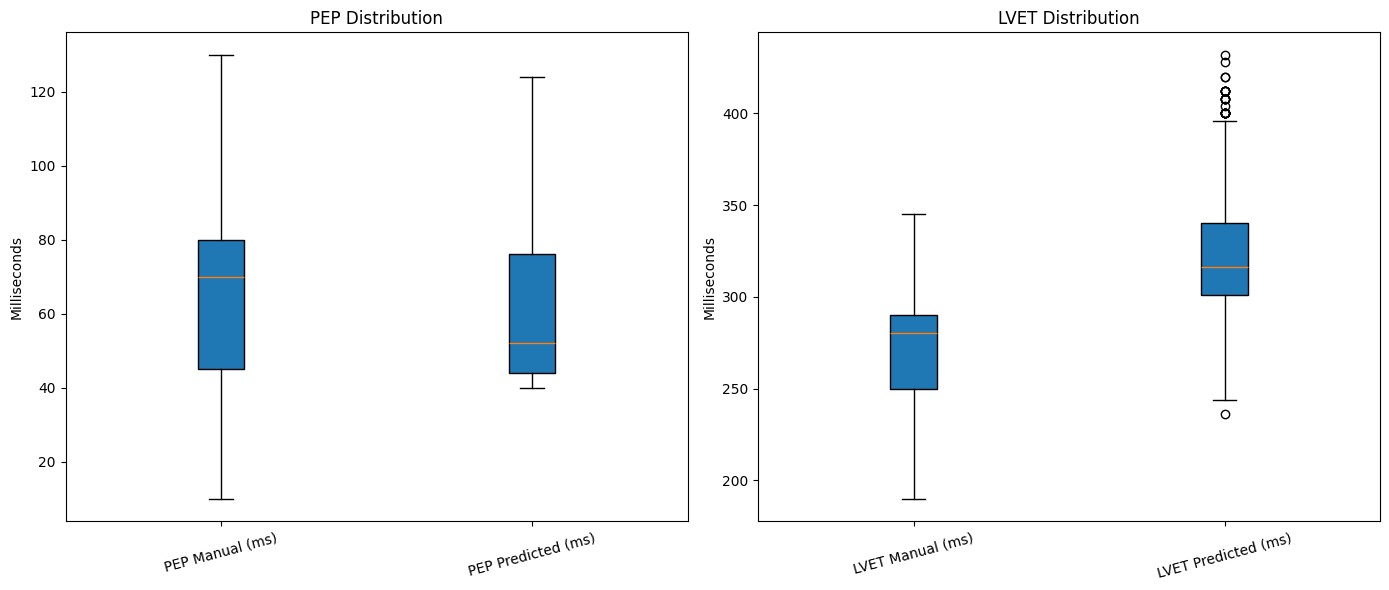

In [89]:
pep_data = [pep_manual_all, pep_pred_all]
lvet_data = [lvet_manual_all, lvet_pred_all]

pep_labels = ['PEP Manual (ms)', 'PEP Predicted (ms)']
lvet_labels = ['LVET Manual (ms)', 'LVET Predicted (ms)']

# Set up plot
plt.figure(figsize=(14, 6))

# PEP boxplot
plt.subplot(1, 2, 1)
plt.boxplot(pep_data, patch_artist=True)
plt.xticks(ticks=[1, 2], labels=pep_labels, rotation=15)
plt.ylabel("Milliseconds")
plt.title("PEP Distribution")

# LVET boxplot
plt.subplot(1, 2, 2)
plt.boxplot(lvet_data, patch_artist=True)
plt.xticks(ticks=[1, 2], labels=lvet_labels, rotation=15)
plt.ylabel("Milliseconds")
plt.title("LVET Distribution")

plt.tight_layout()
plt.show()


In [90]:
# Initialize per-subject metrics
per_subject_results = {}

segment_idx = 0
valid_indices = np.where(valid_mask)[0]
valid_index_map = {idx: i for i, idx in enumerate(valid_indices)}

for filename, data in all_data.items():
    try:
        # Manual measurements
        pep_echo = np.array(data["pep_ms"])
        lvet_echo = np.array(data["lvet_ms"])
        n_segments = len(data["rpeaks_index"])

        # Get global segment indices for this file
        file_segment_indices = list(range(segment_idx, segment_idx + n_segments))

        # Determine which of this file's segments are valid
        valid_in_file = [i for i, global_idx in enumerate(file_segment_indices) if global_idx in valid_index_map]

        # Skip file if no valid segments remain
        if not valid_in_file:
            segment_idx += n_segments
            continue

        # Select only the valid predicted segments for this file
        corrected_indices = [valid_index_map[segment_idx + i] for i in valid_in_file]
        predicted_segments = corrected[corrected_indices]

        # Select corresponding manual values
        pep_echo_valid = pep_echo[valid_in_file]
        lvet_echo_valid = lvet_echo[valid_in_file]

        pep_pred, lvet_pred = [], []

        for (b, c, x, o) in predicted_segments:
            pep_time = ((b - offset) / fs) * 1000
            lvet_time = ((x - b) / fs) * 1000
            pep_pred.append(pep_time)
            lvet_pred.append(lvet_time)

        # Convert to arrays
        pep_pred = np.array(pep_pred)
        lvet_pred = np.array(lvet_pred)

        # Align lengths (should already match, but just in case)
        min_len_pep = min(len(pep_echo_valid), len(pep_pred))
        min_len_lvet = min(len(lvet_echo_valid), len(lvet_pred))

        pep_manual = pep_echo_valid[:min_len_pep]
        pep_pred = pep_pred[:min_len_pep]
        lvet_manual = lvet_echo_valid[:min_len_lvet]
        lvet_pred = lvet_pred[:min_len_lvet]

        # Compute MAEs
        pep_mae = np.mean(np.abs(pep_pred - pep_manual))
        lvet_mae = np.mean(np.abs(lvet_pred - lvet_manual))

        # Store per-subject results
        per_subject_results[filename] = {
            "pep_manual": pep_manual,
            "pep_pred": pep_pred,
            "pep_diff": pep_pred - pep_manual,
            "pep_mae": pep_mae,
            "lvet_manual": lvet_manual,
            "lvet_pred": lvet_pred,
            "lvet_diff": lvet_pred - lvet_manual,
            "lvet_mae": lvet_mae,
            "n_segments": len(pep_manual)
        }

        segment_idx += n_segments

    except Exception as e:
        print(f"Error in file {filename}: {e}")
        continue

<ipython-input-91-855cdbf9014b>:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([pep_maes, lvet_maes], patch_artist=True, labels=["PEP MAE", "LVET MAE"])


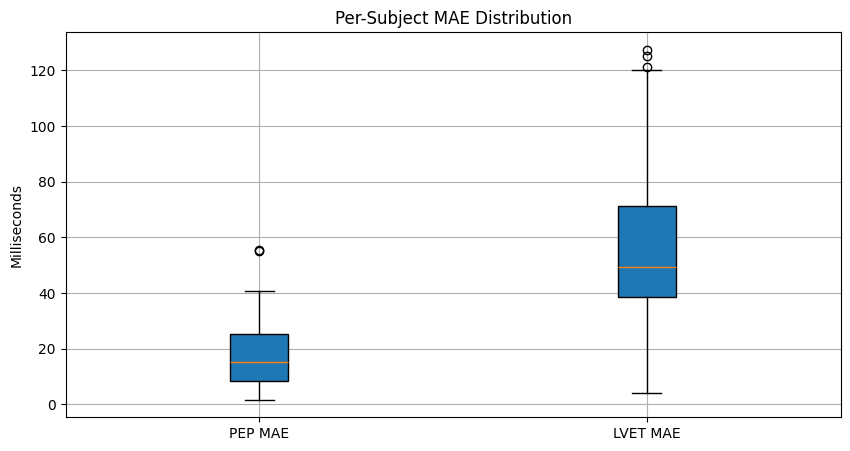

In [91]:
pep_maes = [res["pep_mae"] for res in per_subject_results.values() if not np.isnan(res["pep_mae"])]
lvet_maes = [res["lvet_mae"] for res in per_subject_results.values() if not np.isnan(res["lvet_mae"])]

# Plot
plt.figure(figsize=(10, 5))
plt.boxplot([pep_maes, lvet_maes], patch_artist=True, labels=["PEP MAE", "LVET MAE"])
plt.title("Per-Subject MAE Distribution")
plt.ylabel("Milliseconds")
plt.grid(True)
plt.show()

In [92]:
# --- PEP: % within 20ms and 40ms ---
pep_within_20 = np.nanmean(np.abs(pep_diff) <= 20) * 100
pep_within_40 = np.nanmean(np.abs(pep_diff) <= 40) * 100

# --- LVET: % within 60ms and 80ms ---
lvet_within_60 = np.nanmean(np.abs(lvet_diff) <= 60) * 100
lvet_within_80 = np.nanmean(np.abs(lvet_diff) <= 80) * 100

print(f"\n--- PEP ---")
print("Within ±20 ms: {:.2f}%".format(pep_within_20))
print("Within ±40 ms: {:.2f}%".format(pep_within_40))

print(f"\n--- LVET ---")
print("Within ±60 ms: {:.2f}%".format(lvet_within_60))
print("Within ±80 ms: {:.2f}%".format(lvet_within_80))



--- PEP ---
Within ±20 ms: 62.75%
Within ±40 ms: 91.44%

--- LVET ---
Within ±60 ms: 65.96%
Within ±80 ms: 79.96%


In [ ]:
import pandas as pd
import numpy as np

# Build a DataFrame
subject_df = pd.DataFrame([
    {
        "Subject": fname,
        "Num Segments": res["n_segments"],
        "PEP MAE (ms)": np.round(res["pep_mae"], 2),
        "LVET MAE (ms)": np.round(res["lvet_mae"], 2),
        "Mean PEP (manual)": np.round(np.mean(res["pep_manual"]), 2),
        "Mean LVET (manual)": np.round(np.mean(res["lvet_manual"]), 2)
    }
    for fname, res in per_subject_results.items()
    if not np.isnan(res["pep_mae"]) and not np.isnan(res["lvet_mae"])
])

# Display table
subject_df.sort_values("Subject").reset_index(drop=True)


,Subject,Num Segments,PEP MAE (ms),LVET MAE (ms),Mean PEP (manual),Mean LVET (manual)
0,59146238_s0000001.mat,11,5.73,65.00,49.55,258.64
1,59146238_s0000002.mat,12,5.50,67.58,49.17,261.25
2,59146238_s0000003.mat,10,6.00,79.20,49.00,256.00
3,59146238_s0000004.mat,11,4.82,50.64,49.55,258.64
4,59146238_s0000005.mat,12,8.17,64.92,49.17,261.25
5,59146238_s0000006.mat,10,12.00,33.70,48.00,277.50
6,59146238_s0000007.mat,11,9.91,30.00,48.64,277.27
7,59146238_s0000008.mat,11,9.18,30.55,48.64,277.27
8,59146238_s0000010.mat,11,27.36,110.36,48.64,277.27
9,59146238_s0000011.mat,9,19.56,142.22,74.44,244.44


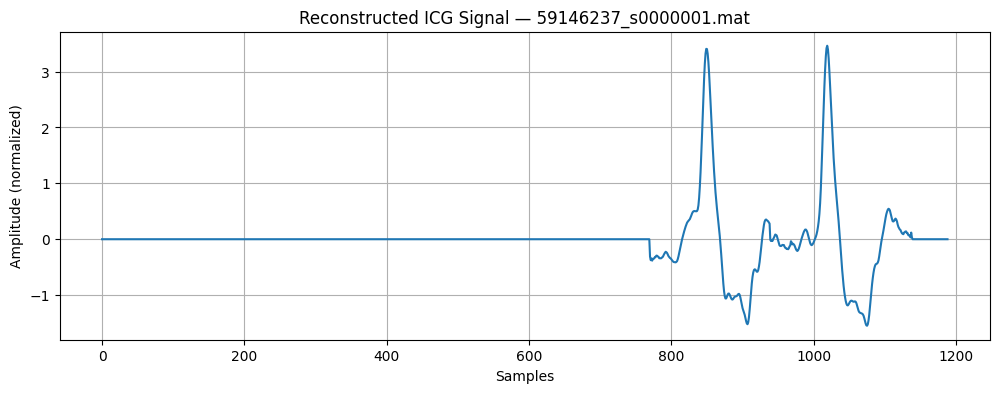

In [54]:
fs = 250
offset = int(0.2 * fs)  # 50 samples
segment_length = X_input_all.shape[1]

# Seleccionar sujeto
subject_name = list(all_data.keys())[0]
subject_data = all_data[subject_name]
rpeaks = subject_data["rpeaks_index"]
n_segments = len(rpeaks)

# Buscar índice global de inicio de este sujeto en X_input_all
segment_idx = 0
for name in list(all_data.keys()):
    if name == subject_name:
        break
    segment_idx += len(all_data[name]["rpeaks_index"])

# Extraer segmentos ICG del sujeto
icg_subject_segments = X_input_all[segment_idx:segment_idx + n_segments, :, 0]  # canal 0 = ICG

# Estimar la longitud de la señal original (último R-peak + 1 ciclo)
estimated_length = rpeaks[-1] + int(0.8 * fs)
icg_full = np.zeros(estimated_length)
count = np.zeros(estimated_length)

# Reconstrucción con solapamiento y promedio
for seg, rpeak in zip(icg_subject_segments, rpeaks):
    start = rpeak - offset
    end = start + segment_length

    if start < 0 or end > len(icg_full):
        continue  # ignorar segmentos incompletos al inicio/final

    icg_full[start:end] += seg
    count[start:end] += 1

# Promediar zonas solapadas
icg_full_avg = np.divide(icg_full, count, out=np.zeros_like(icg_full), where=(count != 0))


plt.figure(figsize=(12, 4))
#plt.plot(icg_full)
plt.plot(icg_full_avg)
plt.title(f"Reconstructed ICG Signal — {subject_name}")
plt.xlabel("Samples")
plt.ylabel("Amplitude (normalized)")
plt.grid(True)
plt.show()


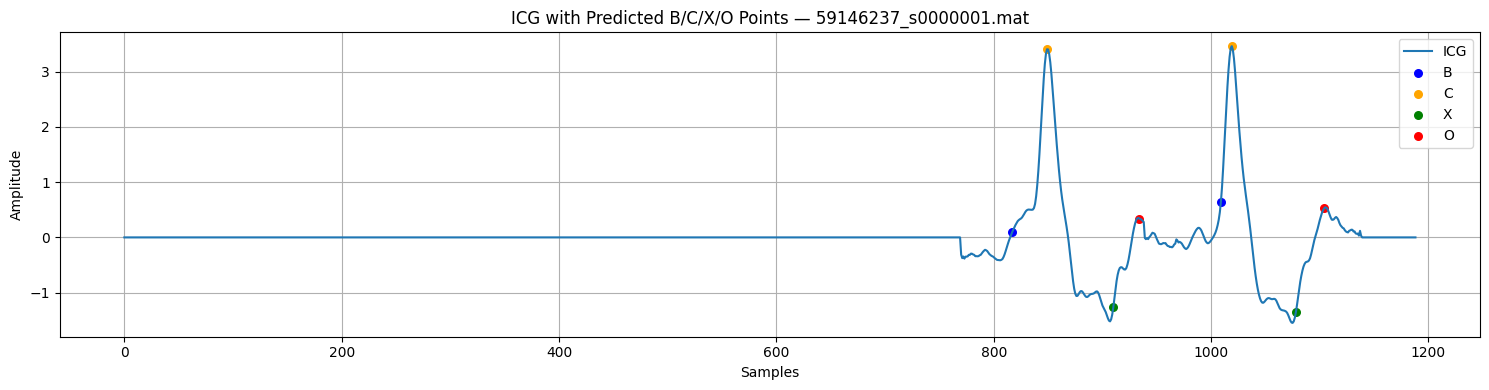

In [55]:
predicted_subject = predicted_b_c_x_o_all[segment_idx:segment_idx + n_segments]

b_points = []
c_points = []
x_points = []
o_points = []

for (b, c, x, o), rpeak in zip(predicted_subject, rpeaks):
    if not np.isnan(b):
        b_points.append(int(rpeak - offset + b))
    if not np.isnan(c):
        c_points.append(int(rpeak - offset + c))
    if not np.isnan(x):
        x_points.append(int(rpeak - offset + x))
    if not np.isnan(o):
        o_points.append(int(rpeak - offset + o))

plt.figure(figsize=(15, 4))
plt.plot(icg_full_avg, label='ICG')

plt.scatter(b_points, icg_full_avg[b_points], color='blue', label='B', s=30)
plt.scatter(c_points, icg_full_avg[c_points], color='orange', label='C', s=30)
plt.scatter(x_points, icg_full_avg[x_points], color='green', label='X', s=30)
plt.scatter(o_points, icg_full_avg[o_points], color='red', label='O', s=30)

plt.title(f"ICG with Predicted B/C/X/O Points — {subject_name}")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [56]:
# calculate RR intervals in milliseconds
rr_intervals_ms = np.diff(rpeaks_index) * 1000 / fs
print("RR intervals (ms):")
print(rr_intervals_ms)
print("Total RR intervals:", len(rr_intervals_ms))
print('Mean RR interval:', np.mean(rr_intervals_ms), 'ms')

RR intervals (ms):
[576. 604. 604. 568. 548. 576. 564. 564. 540. 592.]
Total RR intervals: 10
Mean RR interval: 573.6 ms


In [57]:


import numpy as np
# Calculate standard deviation of rr_intervals_ms
std_rr_intervals_ms = np.std(rr_intervals_ms)
print("Standard Deviation of RR intervals:", std_rr_intervals_ms, "ms")


Standard Deviation of RR intervals: 20.489997559785117 ms
